### 비지도 학습 예제 1

#### 와인 품질 데이터로 클러스터링을 활용한 품질 분류
- Kaggle의 "[Red Wine Quality Dataset](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009/data)"을 사용

##### 문제
- **데이터 준비 및 전처리**
    - "Red Wine Quality Dataset"을 로드하고, 주요 특성(와인의 화학적 특성)을 선택하세요.
    - 데이터를 정규화하여 클러스터링을 위한 준비를 하세요.
    - 주요 열은 와인의 화학적 특성('fixed acidity', 'volatile acidity' 등)과 품질 점수(quality)
- **K-Means 클러스터링 적용**
    - 클러스터 수를 3으로 설정하고 K-Means 알고리즘을 사용해 클러스터링을 수행하세요.
    - 각 데이터 포인트의 클러스터 레이블을 데이터프레임에 추가하세요.
- **클러스터 품질 해석**
    - 각 클러스터의 특성을 분석하고 평균값을 비교하여 클러스터별 차이를 해석하세요.
    - 각 클러스터가 특정 와인 품질(quality) 점수와 관련이 있는지 탐색하세요.
- **결과 시각화**
    - PCA를 사용해 데이터를 2차원으로 축소하고 클러스터링 결과를 시각화하세요.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
# 데이터 준비
df = pd.read_csv('winequality-red.csv')

# 데이터 전처리
features = df.drop("quality", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

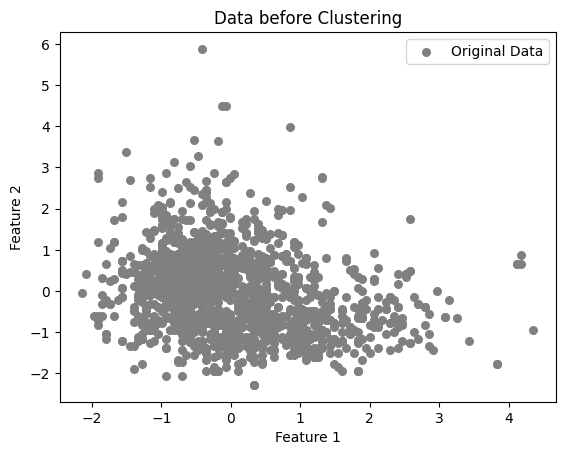

In [3]:
# 2. 데이터 시각화 (군집화 전)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=30, c='gray', label="Original Data")
plt.title("Data before Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

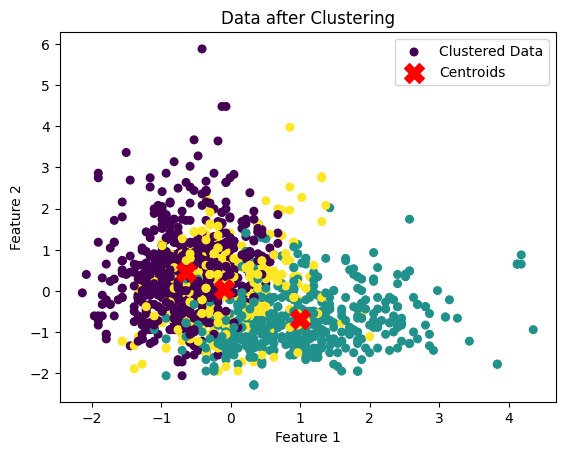

In [4]:
# K-Means 클러스터링 적용
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

# 군집화 결과 시각화
plt.scatter(
    X_scaled[: , 0], X_scaled[:, 1],
    c=clusters, cmap='viridis', s=30, label='Clustered Data'
)
plt.scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    s=200, c='red', label="Centroids", marker='X'
)
plt.title("Data after Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# 결과 데이터프레임에 추가
df['cluster'] = clusters

         fixed acidity  volatile acidity  citric acid  residual sugar  \
cluster                                                                 
0             7.189889          0.609342     0.123047        2.214058   
1            10.067131          0.405080     0.469761        2.582570   
2             8.155467          0.535173     0.289680        3.105467   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
cluster                                                                   
0         0.078553            13.507618             34.894737  0.995896   
1         0.100460            10.888446             30.627490  0.997574   
2         0.087235            27.108000             89.954667  0.997276   

               pH  sulphates    alcohol   quality  
cluster                                            
0        3.405762   0.609224  10.494044  5.552632  
1        3.195040   0.752131  10.724037  5.960159  
2        3.284267   0.626533   9.883156  5.362667 

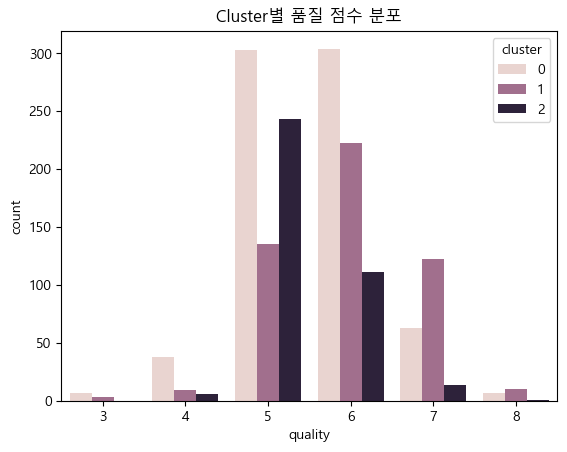

In [5]:
# 클러스터 품질 해석
cluster_means = df.groupby("cluster").mean()
print(cluster_means)

# 한글 폰트 설정
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

# 클러스터별 품질 점수 분포 확인
sns.countplot(x="quality", hue="cluster", data=df)
plt.title("Cluster별 품질 점수 분포")
plt.show()

In [6]:
# 품질 평균 확인
quality_by_cluster = df.groupby('cluster')['quality'].mean()
print(quality_by_cluster)

cluster
0    5.552632
1    5.960159
2    5.362667
Name: quality, dtype: float64


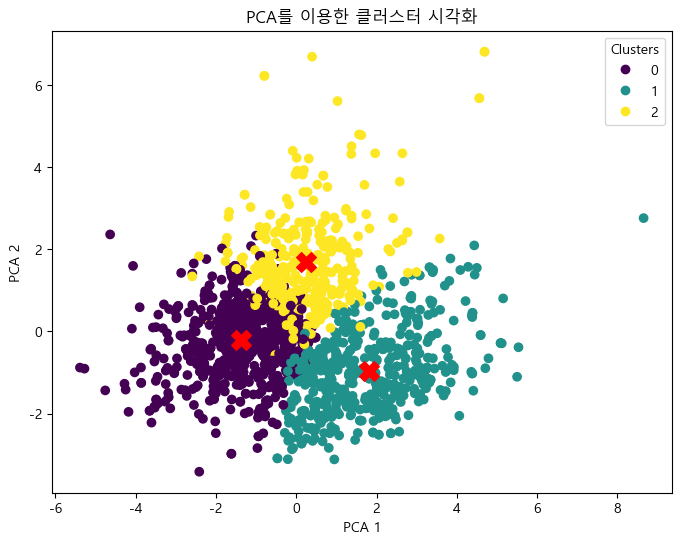

In [7]:
# 결과 시각화(PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 클러스터 중심도 PCA
centroids = kmeans.cluster_centers_           # 클러스터 중심 (스케일된 공간에서)
centroids_pca = pca.transform(centroids)      # PCA 공간으로 투영

# 시각화
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df["cluster"], cmap="viridis")
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    s=200, c='red', label="Centroids", marker='X'
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA를 이용한 클러스터 시각화")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

### 비지도학습  2- 신용카드 거래 데이터

#### 신용카드 거래 데이터(Credit Card Fraud Detection)
- Kaggle - [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

##### 문제

- **실제 신용카드 거래 데이터(28개의 익명화된 특성 + 시간, 금액)**
- 정상 거래(0)와 이상 거래(1)가 극도로 불균형(이상치 비율 0.17%) → **이상치 탐지 목적에 최적**
- 라벨이 있지만, 비지도학습 실습용으로 라벨을 감추고 사용
- Isolation Forest, DBSCAN 등 비지도 학습 알고리즘을 적용하고 성능 비교

신용카드 부정 거래를 탐지하는 모델 훈련

- 주어진 신용카드 거래 데이터를 기반으로 부정 거래를 식별하는 모델을 학습시키고, 이 모델을 통해 이상치(부정 거래)를 탐지
- 이 데이터는 각 거래의 다양한 특성과 `Class`라는 열로 부정 거래 여부를 표시
- `Class` 값이 **1**이면 부정 거래, **0**이면 정상 거래를 의미
- 이상치(부정 거래)를 정확하게 탐지하는 것

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

In [9]:
# 데이터 수집
df = pd.read_csv('creditcard.csv')

# 데이터 전처리
labels = df['Class']
X = df.drop('Class', axis=1)

# 데이터 스케일링
X['Amount'] = StandardScaler().fit_transform(X[['Amount']])
X['Time'] = StandardScaler().fit_transform(X[['Time']])

In [10]:
# Isolation Forest 모델 생성 및 학습
model_iso = IsolationForest(contamination=0.0017, random_state=42)
y_pred_iso = model_iso.fit_predict(X)
# Isolation Forest는 정상은 1, 이상치는 -1로 예측
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

In [11]:
# # DBSCAN 적용
# X_pca = PCA(n_components=2).fit_transform(X)

# dbscan = DBSCAN(eps=1.5, min_samples=5)
# y_pred_dbscan = dbscan.fit_predict(X)

# # DBSCAN에서 -1은 이상치
# y_pred_dbscan = [1 if x == -1 else 0 for x in y_pred_dbscan]

In [12]:
# 성능 평가
print("Isolation Forest")
print(confusion_matrix(labels, y_pred_iso))
print(classification_report(labels, y_pred_iso))

# print("DBSCAN")
# print(confusion_matrix(labels, y_pred_dbscan))
# print(classification_report(labels, y_pred_dbscan))

Isolation Forest
[[283955    360]
 [   367    125]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.26      0.25      0.26       492

    accuracy                           1.00    284807
   macro avg       0.63      0.63      0.63    284807
weighted avg       1.00      1.00      1.00    284807

